<a href="https://colab.research.google.com/github/dhiru69-tech/ML-Techniques-Lab-Project/blob/main/DAY2_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

data = fetch_openml(name="credit-g", version=1, as_frame=True)
df = data.frame
print(df.shape)

(1000, 21)


In [ ]:
print(df['class'].value_counts())
print(df['class'].value_counts(normalize=True) * 100)

class
good    700
bad     300
Name: count, dtype: int64
class
good    70.0
bad     30.0
Name: proportion, dtype: float64


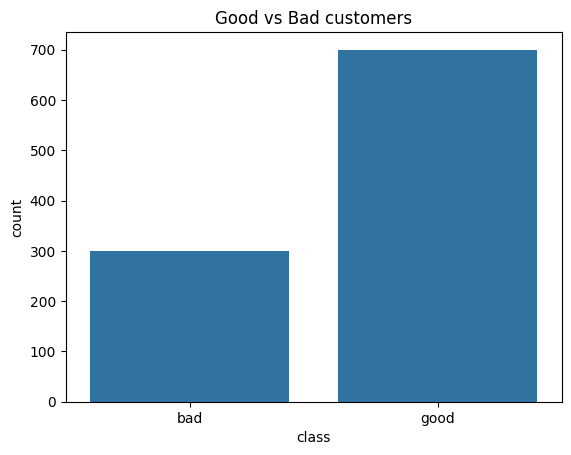

In [ ]:
sns.countplot(x='class', data=df)
plt.title("Good vs Bad customers")
plt.show()

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print(df[num_cols].agg(['mean', 'median']))

        duration  credit_amount  installment_commitment  residence_since  \
mean      20.903       3271.258                   2.973            2.845   
median    18.000       2319.500                   3.000            3.000   

           age  existing_credits  num_dependents  
mean    35.546             1.407           1.155  
median  33.000             1.000           1.000  


In [ ]:
for col in ['checking_status', 'purpose', 'job']:
    print(col)
    print(df[col].value_counts())
    print()

checking_status
checking_status
no checking    394
<0             274
0<=X<200       269
>=200           63
Name: count, dtype: int64

purpose
purpose
radio/tv               280
new car                234
furniture/equipment    181
used car               103
business                97
education               50
repairs                 22
domestic appliance      12
other                   12
retraining               9
Name: count, dtype: int64

job
job
skilled                      630
unskilled resident           200
high qualif/self emp/mgmt    148
unemp/unskilled non res       22
Name: count, dtype: int64



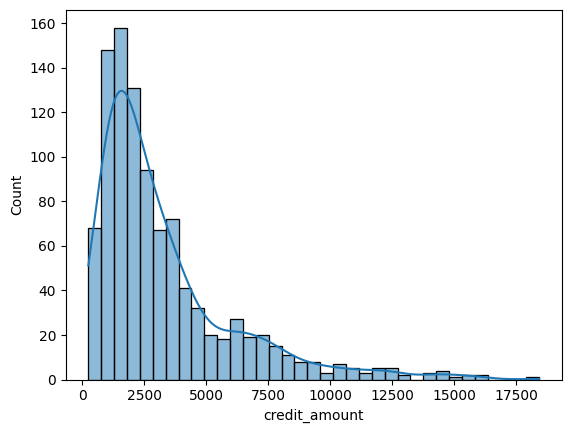

In [ ]:
sns.histplot(df['credit_amount'], kde=True)
plt.show()

In [ ]:
print(df.duplicated().sum())

0


## 5. Outliers

**Outlier:** a value far away from the rest (e.g. one person 8 feet tall in a class of 5-footers).

**How to read a boxplot:**
- **Box** = the middle 50% of the data
- **Line inside the box** = median
- **Whiskers** = normal range
- **Dots outside** = outliers

> **Note:** an outlier is not always an error. A very large loan can be real, so we **inspect first, remove later (if at all).**


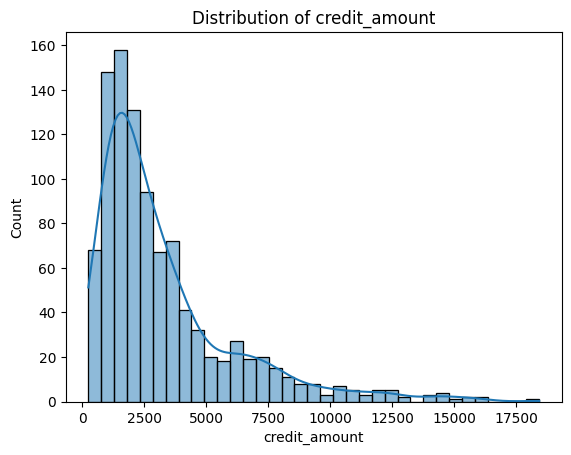

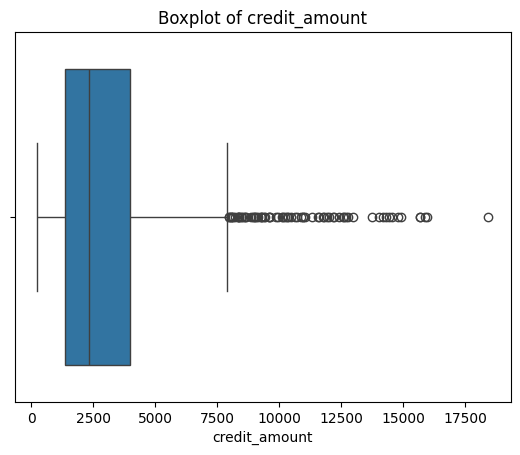

In [ ]:
# Histogram: shows how many customers fall in each loan-amount range
# kde=True adds a smooth curve to show the overall shape
sns.histplot(df['credit_amount'], kde=True)
plt.title("Distribution of credit_amount")
plt.show()

# Boxplot: dots on the right side are the outliers (very large loans)
sns.boxplot(x=df['credit_amount'])
plt.title("Boxplot of credit_amount")
plt.show()
